# Train Fraction vs Test Individual Spillover CI Length

This notebook plots `train_fraction` against the **pointwise mean interval length** for:
- target: `individual_spillover`
- split: `test`
- alpha levels: `0.05` and `0.1`
- nuisance modes: fitted and oracle

The final figure overlays four lines on one plot.

In [18]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

RESULTS_DIR = Path("results")
GLOB_PATTERN = "metrics_SBM_n3000_K3_sbm_separate_self_nuis-*_B200_a0p05_mij_*.json"
TARGET = "individual_spillover"
SPLIT = "test"
ALPHA_MAP = {
    "alpha_0p05": 0.05,
    "alpha_0p1": 0.1,
}


def extract_pointwise_mean(path: Path, alpha_key: str):
    with path.open("r") as f:
        m = json.load(f)

    exp = m.get("experiment", {})
    nuisance = m.get("nuisance", {})
    train_cfg_attn = m.get("train_cfg_attn", {})
    cov_alpha = m.get("coverage_by_alpha_k", {}).get(alpha_key, {})
    block = cov_alpha.get("default", {})
    split_block = block.get(SPLIT, {})
    target_block = split_block.get(TARGET, {})

    b_total = target_block.get("B_total")
    by_prefix = target_block.get("by_prefix", {})
    if b_total is None:
        return None

    final_entry = by_prefix.get(str(b_total), {})
    pointwise_mean = (
        final_entry
        .get("length_summary", {})
        .get("pointwise", {})
        .get("mean")
    )

    if pointwise_mean is None:
        return None

    nuis_label = "fitted" if nuisance.get("fit_nuisance", False) else "oracle"

    return {
        "file": path.name,
        "seed": train_cfg_attn.get("seed"),
        "train_fraction": float(exp.get("train_fraction")),
        "nuisance": nuis_label,
        "alpha_key": alpha_key,
        "alpha": ALPHA_MAP[alpha_key],
        "pointwise_length_mean": float(pointwise_mean),
    }


rows = []
for p in sorted(RESULTS_DIR.glob(GLOB_PATTERN)):
    for alpha_key in ALPHA_MAP:
        rec = extract_pointwise_mean(p, alpha_key)
        if rec is not None:
            rows.append(rec)

if not rows:
    raise RuntimeError("No matching records found. Check results directory and metric schema.")

df = pd.DataFrame(rows).sort_values(["nuisance", "alpha", "train_fraction", "seed"])
display(df)

# Average across seeds (or repeated runs) at each train_fraction
agg = (
    df.groupby(["nuisance", "alpha", "train_fraction"], as_index=False)
      .agg(
          mean_pointwise_length=("pointwise_length_mean", "mean"),
          sd_pointwise_length=("pointwise_length_mean", "std"),
          n=("pointwise_length_mean", "size"),
      )
      .sort_values(["nuisance", "alpha", "train_fraction"])
)

# If a group has one run, std is NaN; use 0 so ribbon collapses to the line.
agg["sd_pointwise_length"] = agg["sd_pointwise_length"].fillna(0.0)

display(agg)



,file,seed,train_fraction,nuisance,alpha_key,alpha,pointwise_length_mean
22,metrics_SBM_n3000_K3_sbm_separate_self_nuis-fi...,1,0.1,fitted,alpha_0p05,0.05,1.987615
44,metrics_SBM_n3000_K3_sbm_separate_self_nuis-fi...,2,0.1,fitted,alpha_0p05,0.05,2.309968
66,metrics_SBM_n3000_K3_sbm_separate_self_nuis-fi...,3,0.1,fitted,alpha_0p05,0.05,1.484481
88,metrics_SBM_n3000_K3_sbm_separate_self_nuis-fi...,4,0.1,fitted,alpha_0p05,0.05,1.963328
92,metrics_SBM_n3000_K3_sbm_separate_self_nuis-fi...,5,0.1,fitted,alpha_0p05,0.05,1.731121
...,...,...,...,...,...,...,...
183,metrics_SBM_n3000_K3_sbm_separate_self_nuis-or...,2,1.0,oracle,alpha_0p1,0.10,0.179080
185,metrics_SBM_n3000_K3_sbm_separate_self_nuis-or...,3,1.0,oracle,alpha_0p1,0.10,0.193570
187,metrics_SBM_n3000_K3_sbm_separate_self_nuis-or...,4,1.0,oracle,alpha_0p1,0.10,0.185254
191,metrics_SBM_n3000_K3_sbm_separate_self_nuis-or...,5,1.0,oracle,alpha_0p1,0.10,0.186278


,nuisance,alpha,train_fraction,mean_pointwise_length,sd_pointwise_length,n
0,fitted,0.05,0.1,1.895303,0.308556,5
1,fitted,0.05,0.2,1.897068,0.584342,5
2,fitted,0.05,0.3,1.239045,0.136591,5
3,fitted,0.05,0.4,2.355194,0.395850,5
4,fitted,0.05,0.5,1.669847,0.363136,5
5,fitted,0.05,0.6,1.102637,0.139664,5
6,fitted,0.05,0.7,0.997304,0.111418,5
7,fitted,0.05,0.8,0.902724,0.160006,5
8,fitted,0.05,0.9,0.541609,0.080388,5
9,fitted,0.05,1.0,0.399276,0.023342,5


In [19]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt


RESULTS_DIR = Path("results")
GLOB_PATTERN = "metrics_SBM_n3000_K3_sbm_separate_self_nuis-*_B200_a0p05_mij_*.json"
TARGET = "individual_spillover"
SPLIT = "test"
ALPHA_KEY = "alpha_0p05"


def extract_pointwise_mean(path: Path):
    with path.open("r") as f:
        m = json.load(f)

    exp = m.get("experiment", {})
    nuisance = m.get("nuisance", {})
    train_cfg_attn = m.get("train_cfg_attn", {})

    cov_alpha = m.get("coverage_by_alpha_k", {}).get(ALPHA_KEY, {})
    block = cov_alpha.get("default", {})
    split_block = block.get(SPLIT, {})
    target_block = split_block.get(TARGET, {})

    b_total = target_block.get("B_total")
    by_prefix = target_block.get("by_prefix", {})
    if b_total is None:
        return None

    final_entry = by_prefix.get(str(b_total), {})
    pointwise_mean = (
        final_entry
        .get("length_summary", {})
        .get("pointwise", {})
        .get("mean")
    )
    if pointwise_mean is None:
        return None

    nuis_label = "fitted" if nuisance.get("fit_nuisance", False) else "oracle"
    train_size = exp.get("train_nodes_used")
    if train_size is None:
        tf = float(exp.get("train_fraction", 1.0))
        n_total = int(exp.get("n", 1000))
        train_size = int(round(tf * n_total))

    return {
        "file": path.name,
        "seed": train_cfg_attn.get("seed"),
        "train_size": int(train_size),
        "nuisance": nuis_label,
        "pointwise_length_mean": float(pointwise_mean),
    }


rows = []
for p in sorted(RESULTS_DIR.glob(GLOB_PATTERN)):
    rec = extract_pointwise_mean(p)
    if rec is not None:
        rows.append(rec)

if not rows:
    raise RuntimeError("No matching records found. Check results directory and metric schema.")

df = pd.DataFrame(rows).sort_values(["nuisance", "train_size", "seed"])
display(df)

agg = (
    df.groupby(["nuisance", "train_size"], as_index=False)
      .agg(
          mean_width=("pointwise_length_mean", "mean"),
          sd_width=("pointwise_length_mean", "std"),
          n=("pointwise_length_mean", "size"),
      )
      .sort_values(["nuisance", "train_size"])
)
agg["sd_width"] = agg["sd_width"].fillna(0.0)
agg = agg[agg["train_size"] >= 1200].copy()

display(agg)



,file,seed,train_size,nuisance,pointwise_length_mean
11,metrics_SBM_n3000_K3_sbm_separate_self_nuis-fi...,1,300,fitted,1.987615
22,metrics_SBM_n3000_K3_sbm_separate_self_nuis-fi...,2,300,fitted,2.309968
33,metrics_SBM_n3000_K3_sbm_separate_self_nuis-fi...,3,300,fitted,1.484481
44,metrics_SBM_n3000_K3_sbm_separate_self_nuis-fi...,4,300,fitted,1.963328
46,metrics_SBM_n3000_K3_sbm_separate_self_nuis-fi...,5,300,fitted,1.731121
...,...,...,...,...,...
91,metrics_SBM_n3000_K3_sbm_separate_self_nuis-or...,2,3000,oracle,0.210916
92,metrics_SBM_n3000_K3_sbm_separate_self_nuis-or...,3,3000,oracle,0.227026
93,metrics_SBM_n3000_K3_sbm_separate_self_nuis-or...,4,3000,oracle,0.216664
95,metrics_SBM_n3000_K3_sbm_separate_self_nuis-or...,5,3000,oracle,0.216975


,nuisance,train_size,mean_width,sd_width,n
3,fitted,1200,2.355194,0.395850,5
4,fitted,1500,1.669847,0.363136,5
5,fitted,1800,1.102637,0.139664,5
6,fitted,2100,0.997304,0.111418,5
7,fitted,2400,0.902724,0.160006,5
8,fitted,2700,0.541609,0.080388,5
9,fitted,3000,0.399276,0.023342,5
13,oracle,1200,0.649841,0.171855,5
14,oracle,1500,0.445979,0.029598,5
15,oracle,1800,0.459381,0.067017,5


In [20]:
agg = agg[agg["train_size"] > 1200]


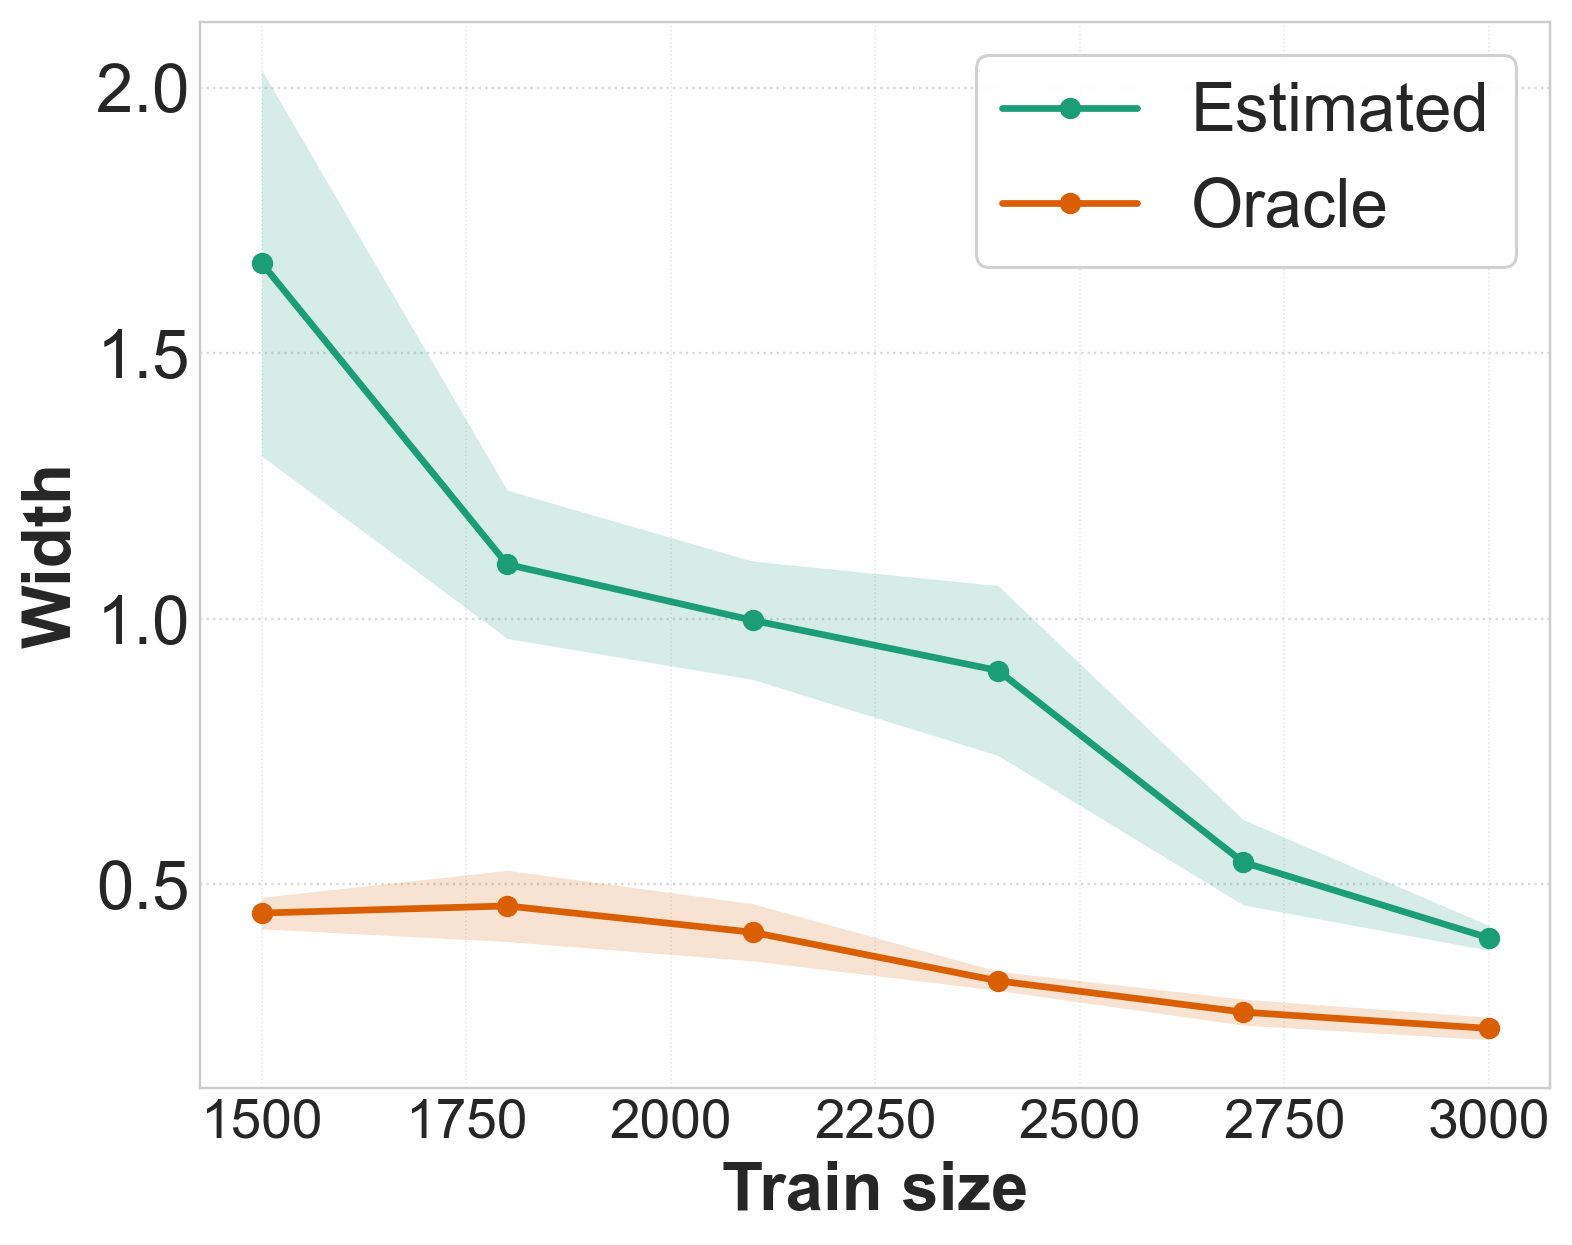

In [21]:
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "figure.dpi": 220,
        "font.size": 18,
        "axes.labelsize": 22,
        "axes.facecolor": "white",
        "figure.facecolor": "white",
        "axes.edgecolor": "0.8",
        "axes.linewidth": 0.8,
        "axes.spines.top": True,
        "axes.spines.right": True,
        "grid.alpha": 0.35,
    }
)


fig, ax = plt.subplots(figsize=(7.5, 6), facecolor="white")
ax.set_facecolor("white")
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("0.8")
    spine.set_linewidth(0.8)

colors = {"fitted": "#1b9e77", "oracle": "#d95f02"}

for nuis, g in agg.groupby("nuisance"):
    g = g.sort_values("train_size")
    x = g["train_size"].to_numpy()
    y = g["mean_width"].to_numpy()
    s = g["sd_width"].to_numpy()
    c = colors.get(nuis, "tab:blue")

    ax.plot(
        x,
        y,
        marker="o",
        color=c,
        linewidth=2.2,
        markersize=6,
        label=nuis,
    )
    ax.fill_between(
        x,
        y - s,
        y + s,
        color=c,
        alpha=0.18,
        linewidth=0,
    )

ax.set_xlabel("Train size", fontweight="bold")
ax.set_ylabel("Width", fontweight="bold")
# ax.set_xticks([500, 600, 700, 800, 900, 1000])
ax.tick_params(axis="y", which="major", labelsize=22)

ax.grid(axis="y", linestyle=":", linewidth=0.8, alpha=0.7)
ax.grid(axis="x", linestyle=":", linewidth=0.5, alpha=0.5)
label_map = {"fitted": "Estimated", "oracle": "Oracle"}
handles, labels = ax.get_legend_handles_labels()
labels = [label_map.get(lbl, lbl) for lbl in labels]
ax.legend(handles, labels, frameon=True, fontsize=22,edgecolor="0.8", framealpha=0.9)
fig.tight_layout()
plt.show()

In [ ]:
# Uniform mean interval length plot (same aesthetics as pointwise plot)
def extract_uniform_mean(path: Path):
    with path.open("r") as f:
        m = json.load(f)

    exp = m.get("experiment", {})
    nuisance = m.get("nuisance", {})
    train_cfg_attn = m.get("train_cfg_attn", {})

    cov_alpha = m.get("coverage_by_alpha_k", {}).get(ALPHA_KEY, {})
    block = cov_alpha.get("default", {})
    split_block = block.get(SPLIT, {})
    target_block = split_block.get(TARGET, {})

    b_total = target_block.get("B_total")
    by_prefix = target_block.get("by_prefix", {})
    if b_total is None:
        return None

    final_entry = by_prefix.get(str(b_total), {})
    uniform_mean = (
        final_entry
        .get("length_summary", {})
        .get("uniform", {})
        .get("mean")
    )
    if uniform_mean is None:
        return None

    nuis_label = "fitted" if nuisance.get("fit_nuisance", False) else "oracle"
    train_size = exp.get("train_nodes_used")
    if train_size is None:
        tf = float(exp.get("train_fraction", 1.0))
        n_total = int(exp.get("n", 1000))
        train_size = int(round(tf * n_total))

    return {
        "file": path.name,
        "seed": train_cfg_attn.get("seed"),
        "train_size": int(train_size),
        "nuisance": nuis_label,
        "uniform_length_mean": float(uniform_mean),
    }


rows_uniform = []
for p in sorted(RESULTS_DIR.glob(GLOB_PATTERN)):
    rec = extract_uniform_mean(p)
    if rec is not None:
        rows_uniform.append(rec)

if not rows_uniform:
    raise RuntimeError("No matching uniform-length records found. Check metric schema.")

df_uniform = pd.DataFrame(rows_uniform).sort_values(["nuisance", "train_size", "seed"])
agg_uniform = (
    df_uniform.groupby(["nuisance", "train_size"], as_index=False)
      .agg(
          mean_width=("uniform_length_mean", "mean"),
          sd_width=("uniform_length_mean", "std"),
          n=("uniform_length_mean", "size"),
      )
      .sort_values(["nuisance", "train_size"])
)
agg_uniform["sd_width"] = agg_uniform["sd_width"].fillna(0.0)
agg_uniform = agg_uniform[agg_uniform["train_size"] > 1200].copy()

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "figure.dpi": 220,
        "font.size": 18,
        "axes.labelsize": 22,
        "axes.facecolor": "white",
        "figure.facecolor": "white",
        "axes.edgecolor": "0.8",
        "axes.linewidth": 0.8,
        "axes.spines.top": True,
        "axes.spines.right": True,
        "grid.alpha": 0.35,
    }
)

fig, ax = plt.subplots(figsize=(7.5, 6), facecolor="white")
ax.set_facecolor("white")
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("0.8")
    spine.set_linewidth(0.8)

colors = {"fitted": "#1b9e77", "oracle": "#d95f02"}

for nuis, g in agg_uniform.groupby("nuisance"):
    g = g.sort_values("train_size")
    x = g["train_size"].to_numpy()
    y = g["mean_width"].to_numpy()
    s = g["sd_width"].to_numpy()
    c = colors.get(nuis, "tab:blue")

    ax.plot(
        x,
        y,
        marker="o",
        color=c,
        linewidth=2.2,
        markersize=6,
        label=nuis,
    )
    ax.fill_between(
        x,
        y - s,
        y + s,
        color=c,
        alpha=0.18,
        linewidth=0,
    )

ax.set_xlabel("Train size", fontweight="bold")
ax.set_ylabel("Uniform width", fontweight="bold")
ax.tick_params(axis="y", which="major", labelsize=22)

ax.grid(axis="y", linestyle=":", linewidth=0.8, alpha=0.7)
ax.grid(axis="x", linestyle=":", linewidth=0.5, alpha=0.5)
label_map = {"fitted": "Estimated", "oracle": "Oracle"}
handles, labels = ax.get_legend_handles_labels()
labels = [label_map.get(lbl, lbl) for lbl in labels]
ax.legend(handles, labels, frameon=True, fontsize=22, edgecolor="0.8", framealpha=0.9)
fig.tight_layout()
plt.show()